In [1]:
import matplotlib as mpl
%matplotlib inline
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'retina'

import numpy as np

import matplotlib.pyplot as plt
import matplotlib.animation as animation

import numpy as np

from tqdm import tqdm

import pandas as pd
from pprint import pprint

import seaborn as sns

from matplotlib import rcParams

rcParams["axes.facecolor"] = "FFFFFF"
rcParams["savefig.facecolor"] = "FFFFFF"
rcParams["xtick.direction"] = "in"
rcParams["ytick.direction"] = "in"

rcParams.update({"figure.autolayout": True})

plt.rcParams["figure.figsize"] = (9,9)


In [63]:
import jax
import jax.numpy as jnp
import jax.random as random
from scipy.stats import nbinom
from jax.example_libraries import optimizers

from fast_negative_binomial import negative_binomial2, log_negative_binomial2_jac

nb_grad = jax.jacrev(jax.scipy.stats.nbinom.logpmf, argnums=[1, 2])

# Assume your custom functions negative_binomial2 and negative_binomial2_jac are defined.
# They take arguments (k, m, r) and return, respectively, the log‐pmf and its jacobian (shape: (len(k), 2)).

# Sample 1000 data points from a negative binomial.
key = random.PRNGKey(0)
true_m, true_r = 10.0, 5.0
p = true_r / (true_r + true_m)
data = nbinom.rvs(true_r, p, size=1000).astype(np.int32)

def loss(params, k):
    r, m = params
    # p = r / (r + m)
    likelihood = negative_binomial2(k, m, r)
    return -np.sum(np.log(likelihood))
    # return -jnp.sum(jax.scipy.stats.nbinom.logpmf(k, r, p))

def loss_grad(params, k):
    r, m = params
    jac = log_negative_binomial2_jac(k, m, r)
    # p = r / (r + m)
    # jac = jnp.vstack(nb_grad(k, r, p)).T
    # return -jnp.mean(jac, axis=0)
    return -jnp.mean(jac, axis = 0)

# Set up the Adam optimizer.
opt_init, opt_update, get_params = optimizers.adam(step_size=5e-2)

# @jax.jit
def step(i, opt_state, k):
    params = get_params(opt_state)
    grads = loss_grad(params, k)
    return opt_update(i, grads, opt_state)

# Initialize parameters (starting guess for m and r).
params0 = jnp.array([10.0, 10.0])
opt_state = opt_init(params0)

for j in tqdm(range(100)):

    losses = []

    # Run the optimization for 1000 iterations.
    # for i in tqdm(range(1000)):
    for i in range(100):
        opt_state = step(i, opt_state, data)
        params = get_params(opt_state)
        losses.append(loss(params, data))

fitted_params = get_params(opt_state)
print("Fitted m: {:.3f}, r: {:.3f}".format(fitted_params[0], fitted_params[1]))


100%|██████████| 100/100 [00:02<00:00, 44.68it/s]

Fitted m: 4.954, r: 10.205


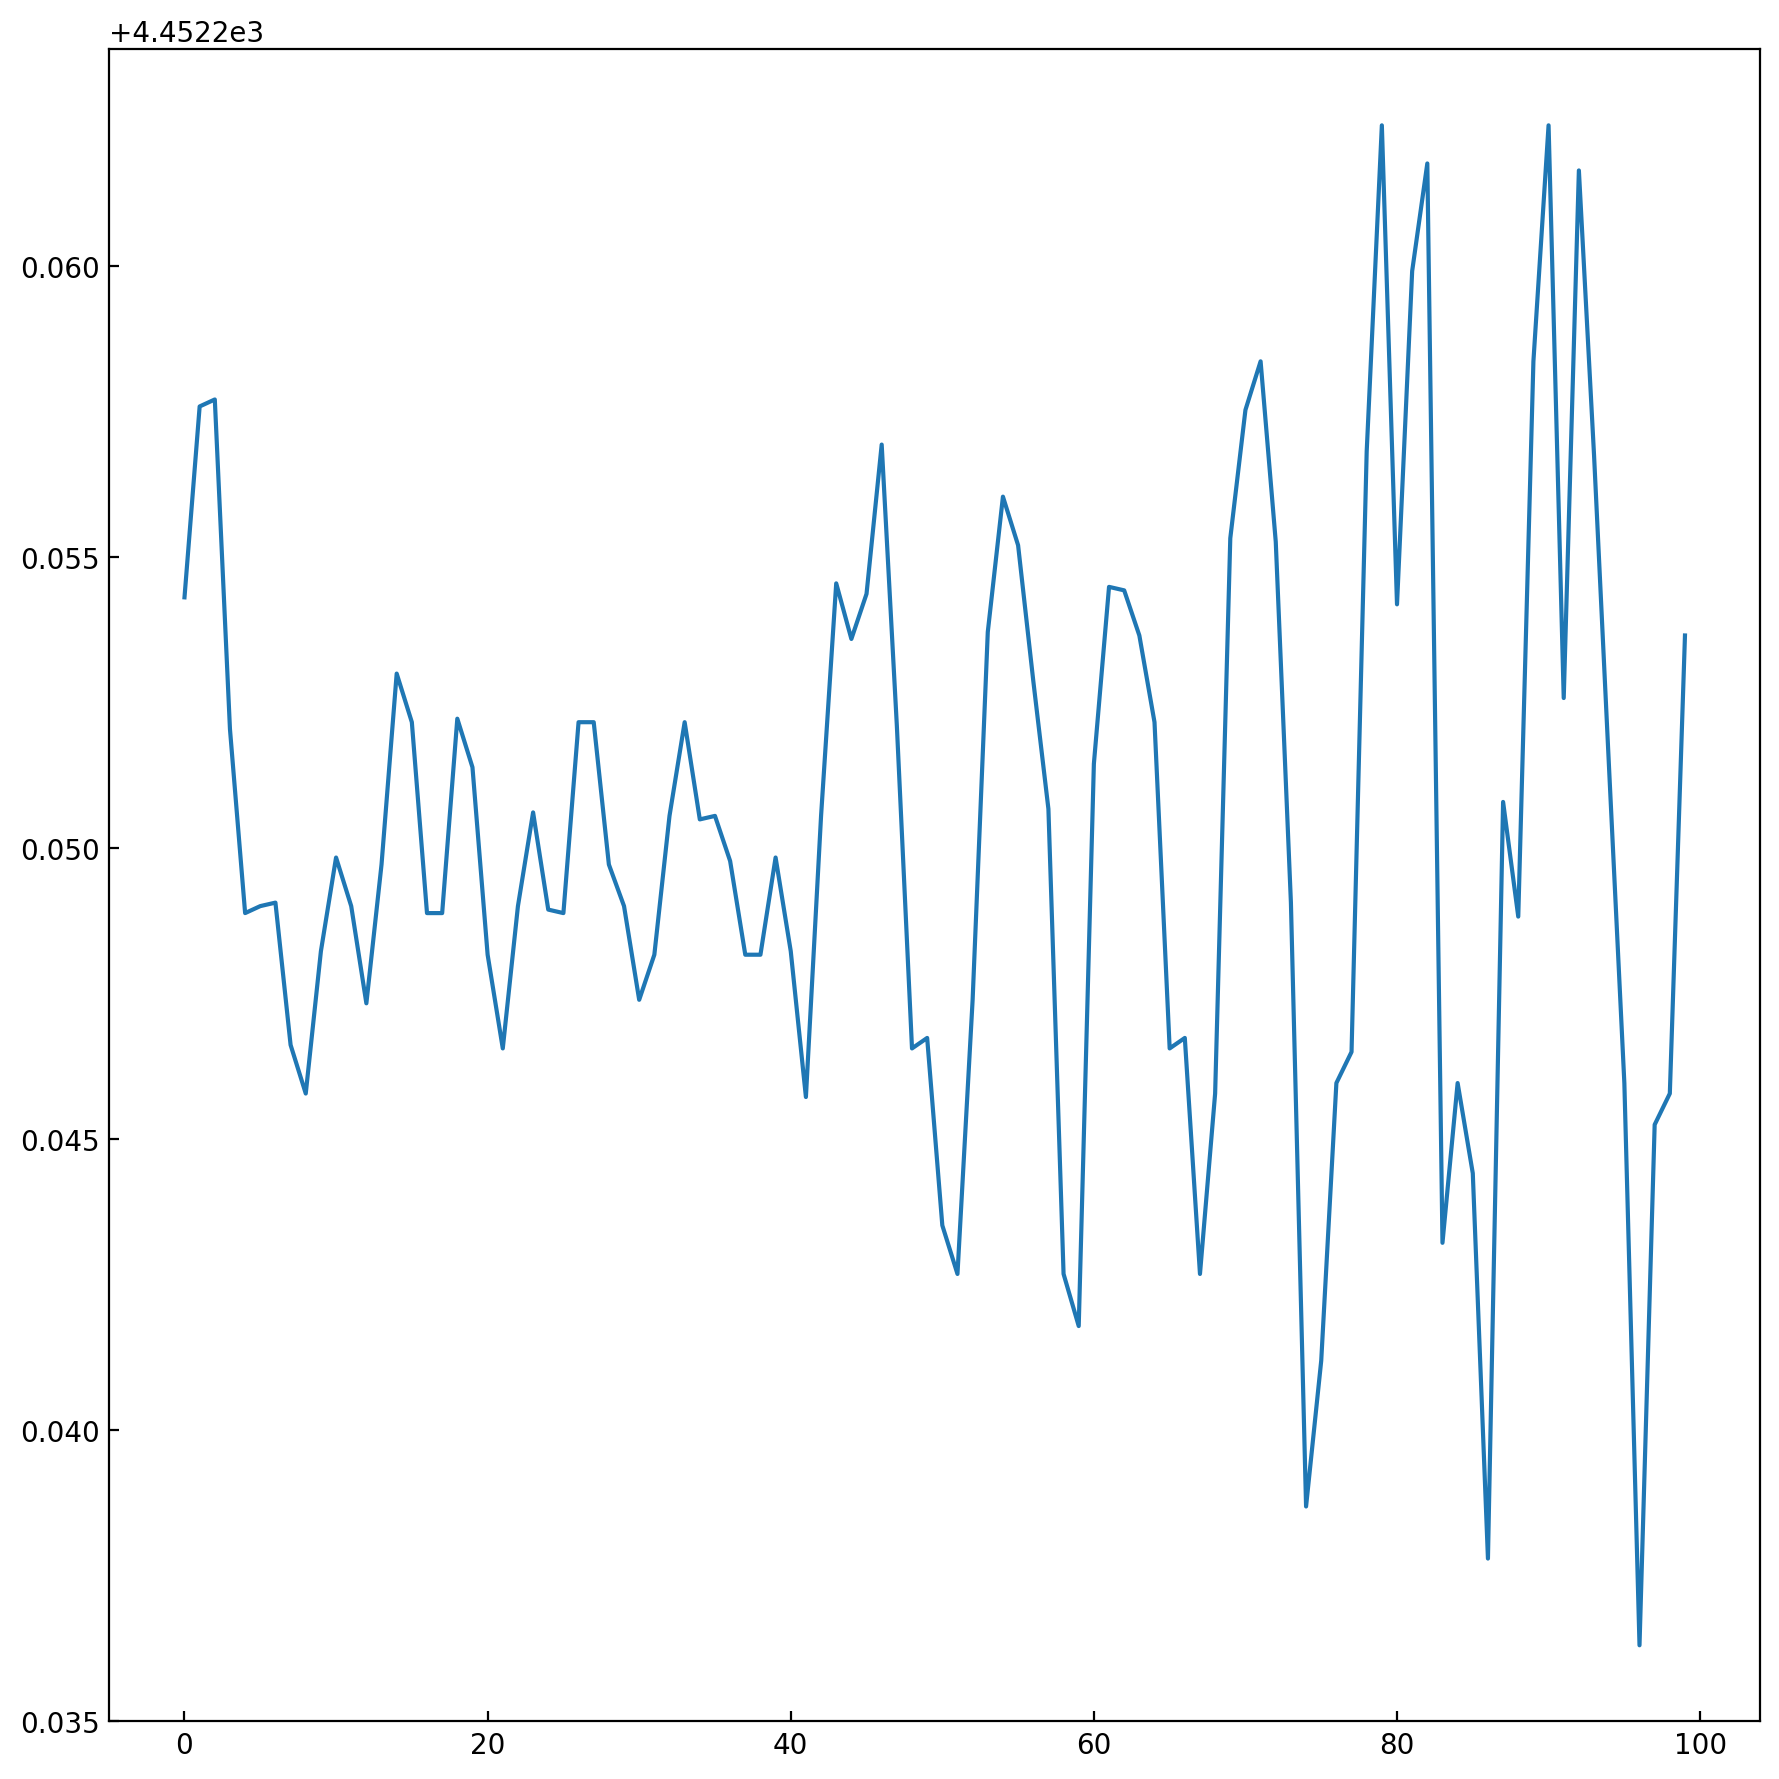

In [64]:
plt.plot(losses)